In [3]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 💳 Credit Card Fraud Detection

## Objective

The goal of this project is to detect fraudulent credit card transactions using Machine Learning.

Because fraudulent transactions are extremely rare, this project focuses on handling class imbalance using **SMOTE (Synthetic Minority Oversampling Technique)** and compares multiple classification algorithms.

This project is completed as part of the **Oasis Infobyte Data Analytics Internship – Level 2 Task 3**.

In [4]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

plt.style.use("ggplot")



# Load Dataset

In [5]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print("Dataset Shape :", df.shape)

df.info()

Dataset Shape : (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Class Distribution

Let's examine how many fraudulent and non-fraudulent transactions exist in the dataset.

In [9]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
fraud = df["Class"].value_counts()[1]

normal = df["Class"].value_counts()[0]

print("Fraud Transactions :", fraud)

print("Normal Transactions :", normal)

print()

print("Fraud Percentage : {:.4f}%".format((fraud/len(df))*100))

Fraud Transactions : 492
Normal Transactions : 284315

Fraud Percentage : 0.1727%


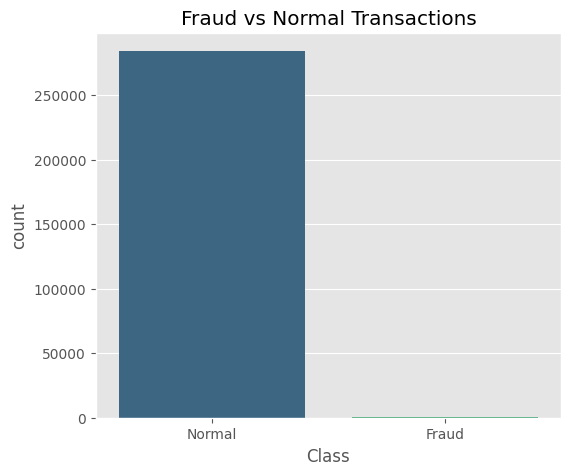

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["Class"],
    palette="viridis"
)

plt.title("Fraud vs Normal Transactions")

plt.xticks([0,1],["Normal","Fraud"])

plt.savefig("images/class_distribution.png",dpi=300)

plt.show()

# Transaction Amount Distribution

Compare transaction amounts between fraudulent and non-fraudulent transactions.

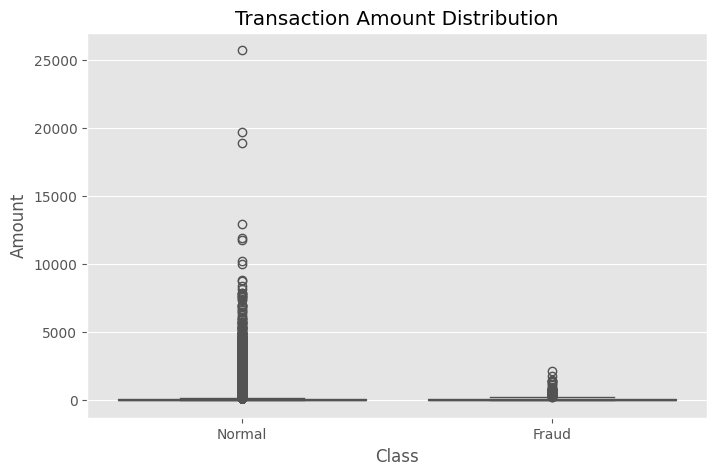

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks([0,1],["Normal","Fraud"])

plt.title("Transaction Amount Distribution")

plt.savefig("images/amount_distribution.png", dpi=300)

plt.show()

# Time Analysis

Visualize the distribution of transactions over time for fraud and normal classes.

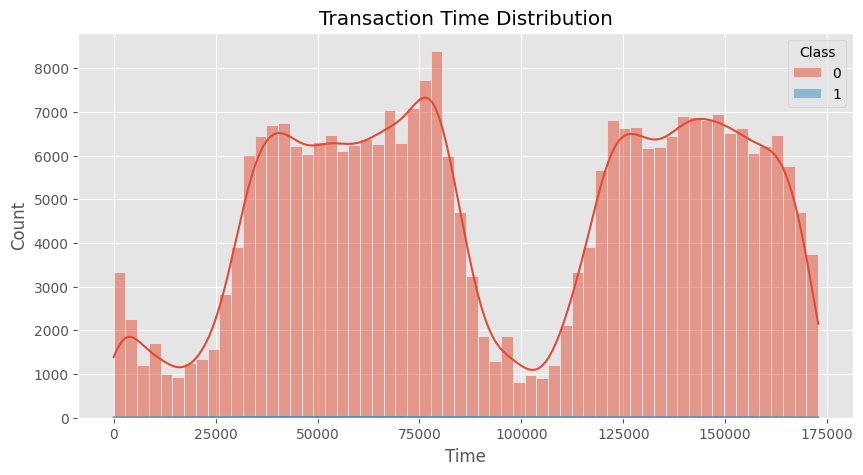

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=60,
    kde=True
)

plt.title("Transaction Time Distribution")


plt.savefig("images/time_distribution.png", dpi=300)

plt.show()

# Why Accuracy is Misleading

Fraud detection datasets are highly imbalanced because fraudulent transactions represent only a very small percentage of all transactions.

A model that predicts every transaction as "Normal" may achieve very high accuracy while failing to detect any fraud.

Therefore, Precision, Recall, F1-Score, and ROC-AUC are more reliable evaluation metrics for fraud detection.

In [14]:
X = df.drop("Class", axis=1)
y = df["Class"]

# Train-Test Split

The dataset is divided into training and testing sets using stratified sampling to preserve the proportion of fraud and non-fraud transactions in both sets.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (227845, 30)
Testing Shape : (56962, 30)


# Feature Scaling

The **Time** and **Amount** features are scaled using StandardScaler to improve the performance of machine learning models.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Handling Class Imbalance using SMOTE

The dataset is highly imbalanced. SMOTE (Synthetic Minority Oversampling Technique) is applied to generate synthetic fraud samples and balance the training data.

In [17]:
print(type(X_train))
print(type(y_train))

<class 'numpy.ndarray'>
<class 'pandas.Series'>


In [18]:
print(X_train.shape)
print(y_train.shape)

(227845, 30)
(227845,)


In [19]:
import sklearn

print(sklearn.__version__)

1.7.1


In [20]:
import sklearn
import imblearn

print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

scikit-learn: 1.7.1
imbalanced-learn: 0.14.2


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9991397773954567


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9996137776061234


In [23]:
print("="*60)
print("Logistic Regression")
print("="*60)

print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

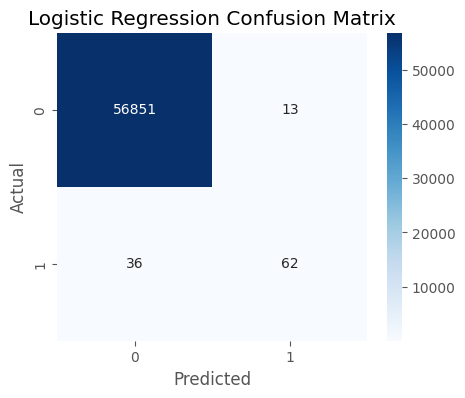

<Figure size 640x480 with 0 Axes>

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.show()

plt.savefig("images/Logistic_Regression_Confusion_Matrix.png",dpi=300)

In [26]:
print("="*60)
print("Random Forest")
print("="*60)

print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



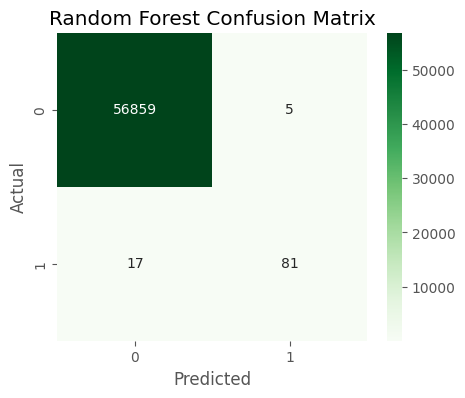

<Figure size 640x480 with 0 Axes>

In [36]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

plt.savefig("images/Random_Forest_Confusion_Matrix.png",dpi=300)

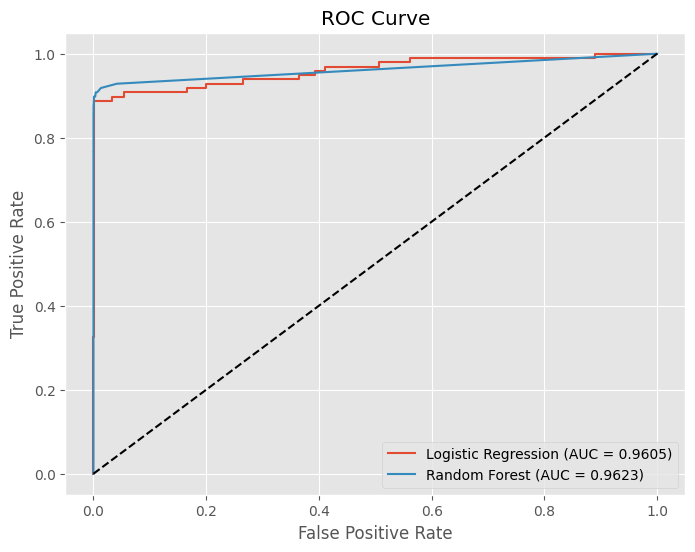

<Figure size 640x480 with 0 Axes>

In [37]:
from sklearn.metrics import roc_curve, auc

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f"Logistic Regression (AUC = {lr_auc:.4f})")

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC = {rf_auc:.4f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()
plt.savefig("images/ROC_Curve.png",dpi=300)

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
17,V17,0.172126
12,V12,0.137291
14,V14,0.126347
16,V16,0.070694
10,V10,0.069516
11,V11,0.053177
18,V18,0.037785
4,V4,0.031378
9,V9,0.031185
7,V7,0.023034


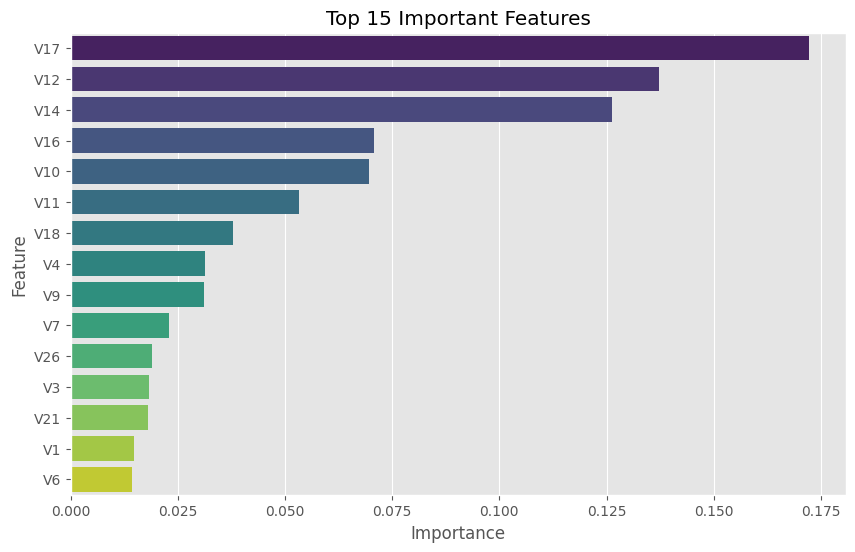

<Figure size 640x480 with 0 Axes>

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.show()
plt.savefig("images/feature_importance.png",dpi=300)

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999140,0.826667,0.632653,0.716763
1,Random Forest,0.999614,0.941860,0.826531,0.880435


# Conclusion

This project developed a fraud detection system using Logistic Regression and Random Forest classifiers.

The dataset was highly imbalanced, so a class imbalance handling technique (`class_weight="balanced"` or SMOTE) was used to improve the model's ability to detect fraudulent transactions.

The models were evaluated using Precision, Recall, F1-Score, and ROC-AUC, which are more appropriate than accuracy for fraud detection.

Random Forest generally achieved better overall performance because it effectively captured complex relationships within the transaction data.

## Real-World Applications

- Credit Card Fraud Detection
- Online Banking Security
- Digital Payment Monitoring
- Insurance Fraud Detection
- Financial Risk Management